In [1]:
import pandas as pd

df = pd.read_csv('data.csv')
print(df.describe())
print(df.head())

        acousticness   danceability   duration_ms         energy  \
count  169909.000000  169909.000000  1.699090e+05  169909.000000   
mean        0.493214       0.538150  2.314062e+05       0.488593   
std         0.376627       0.175346  1.213219e+05       0.267390   
min         0.000000       0.000000  5.108000e+03       0.000000   
25%         0.094500       0.417000  1.710400e+05       0.263000   
50%         0.492000       0.548000  2.086000e+05       0.481000   
75%         0.888000       0.667000  2.629600e+05       0.710000   
max         0.996000       0.988000  5.403500e+06       1.000000   

            explicit  instrumentalness            key       liveness  \
count  169909.000000     169909.000000  169909.000000  169909.000000   
mean        0.084863          0.161937       5.200519       0.206690   
std         0.278679          0.309329       3.515257       0.176796   
min         0.000000          0.000000       0.000000       0.000000   
25%         0.000000       

In [2]:
df["release_date"] = df["release_date"].astype(str)
has_month = df["release_date"].str.match(r"^\d{4}-\d{2}(-\d{2})?$")
year = df["release_date"].str[:4].astype(int)
df_clean = df[has_month & (year >= 1980) & (year <= 2020)]
df_clean.to_csv("cleaned.csv", index=False)

df = pd.read_csv('cleaned.csv')
print(df.describe())
print(df.head())

       acousticness  danceability   duration_ms        energy      explicit  \
count  68521.000000  68521.000000  6.852100e+04  68521.000000  68521.000000   
mean       0.273866      0.580277  2.397659e+05      0.621080      0.164358   
std        0.299714      0.176382  9.317969e+04      0.237487      0.370603   
min        0.000000      0.000000  3.008000e+04      0.000000      0.000000   
25%        0.022600      0.467000  1.931470e+05      0.465000      0.000000   
50%        0.146000      0.593000  2.284930e+05      0.651000      0.000000   
75%        0.465000      0.710000  2.710880e+05      0.813000      0.000000   
max        0.996000      0.988000  5.403500e+06      1.000000      1.000000   

       instrumentalness           key      liveness      loudness  \
count      68521.000000  68521.000000  68521.000000  68521.000000   
mean           0.087307      5.282687      0.196434     -8.761657   
std            0.234453      3.557329      0.171563      4.941363   
min         

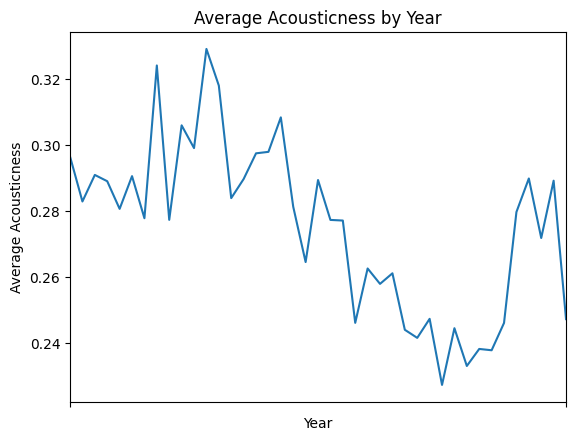

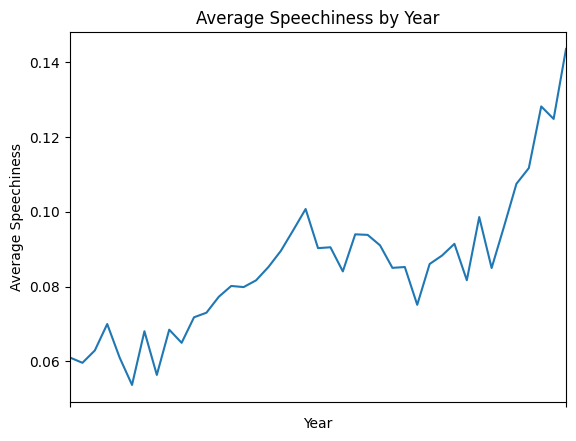

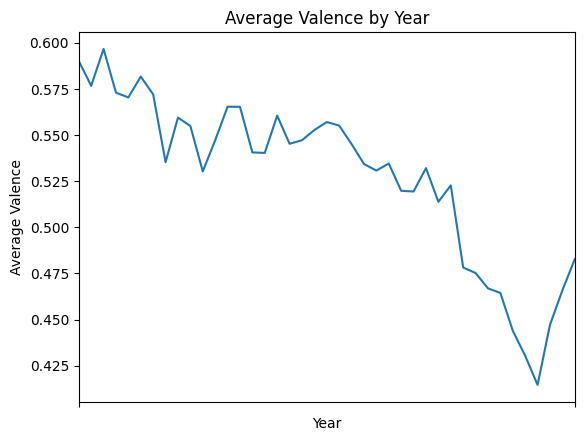

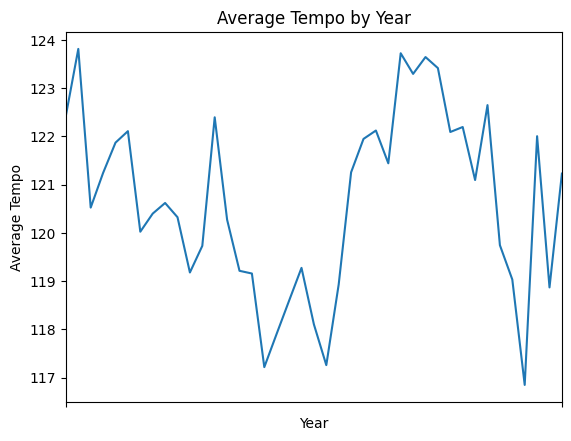

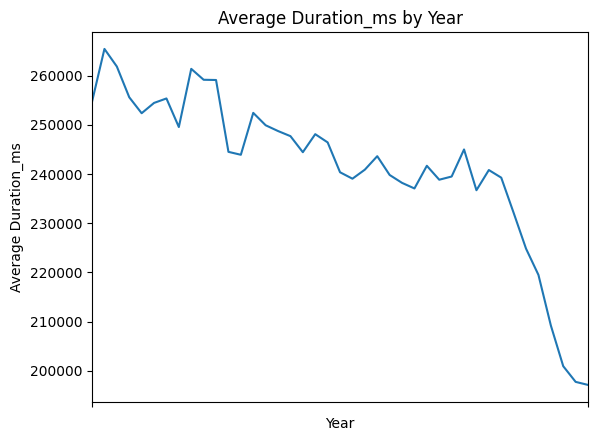

In [3]:
import matplotlib.pyplot as plt

df["year"] = pd.to_datetime(df["year"])

features = ["acousticness", "speechiness", "valence", "tempo", "duration_ms"]


for feature in features:
    plt.figure()
    df.groupby("year")[feature].mean().plot()
    plt.xlabel("Year")
    plt.ylabel(f"Average {feature.capitalize()}")
    plt.title(f"Average {feature.capitalize()} by Year")
    plt.show()

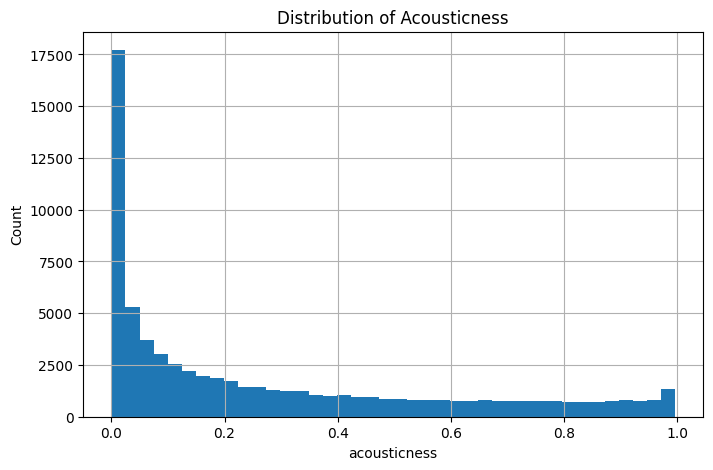

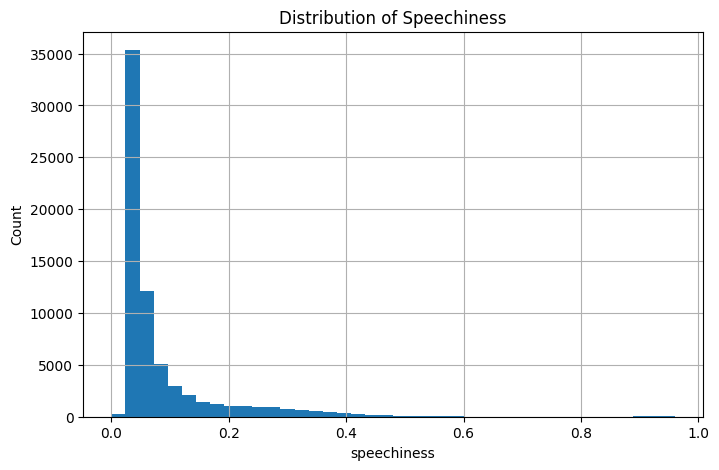

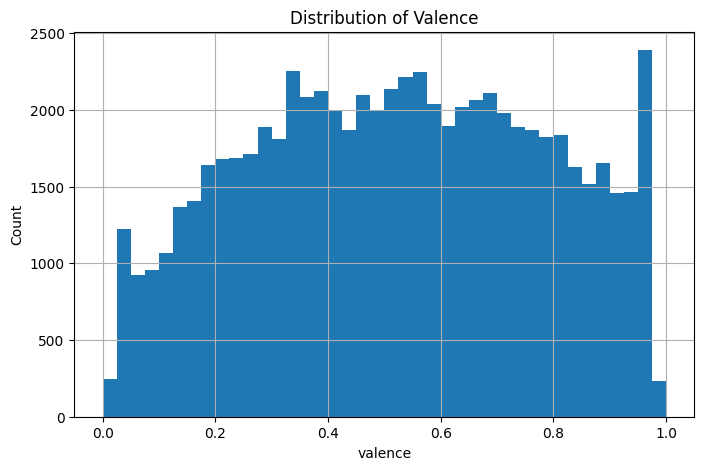

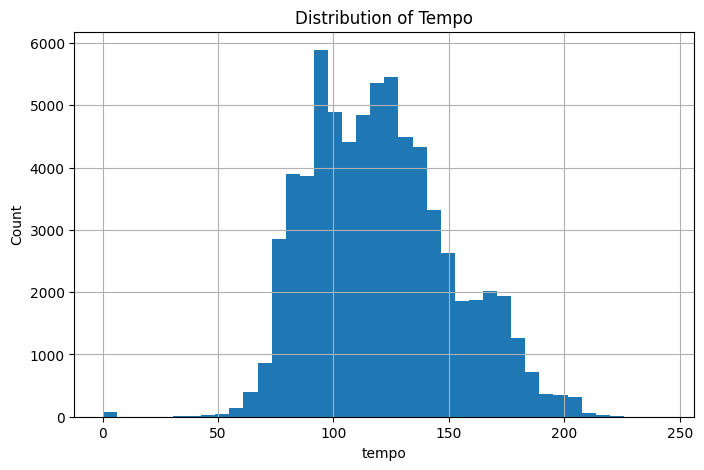

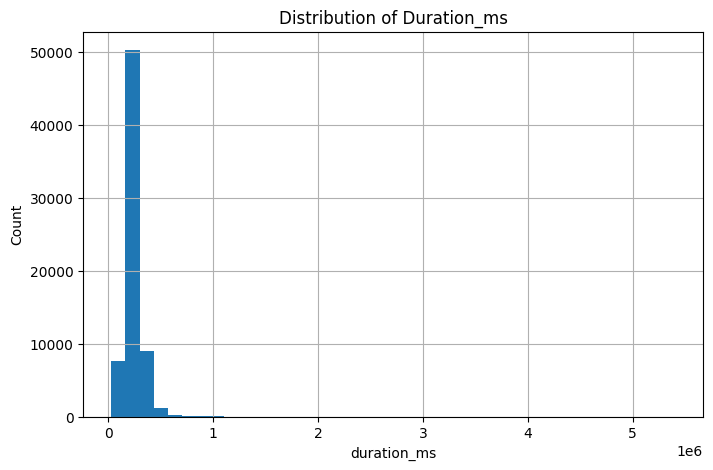

In [4]:
df = pd.read_csv("cleaned.csv")

df["year"] = df["year"].astype(int)

features = ["acousticness", "speechiness", "valence", "tempo", "duration_ms"]

for feature in features:
    plt.figure(figsize=(8, 5))
    df[feature].hist(bins=40)
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.title(f"Distribution of {feature.capitalize()}")
    plt.show()

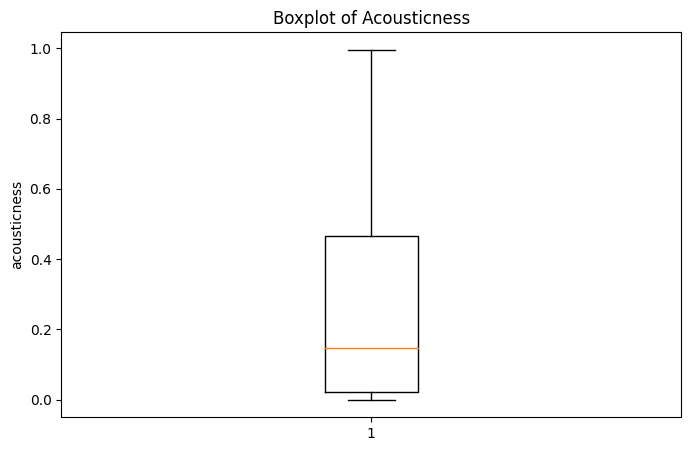

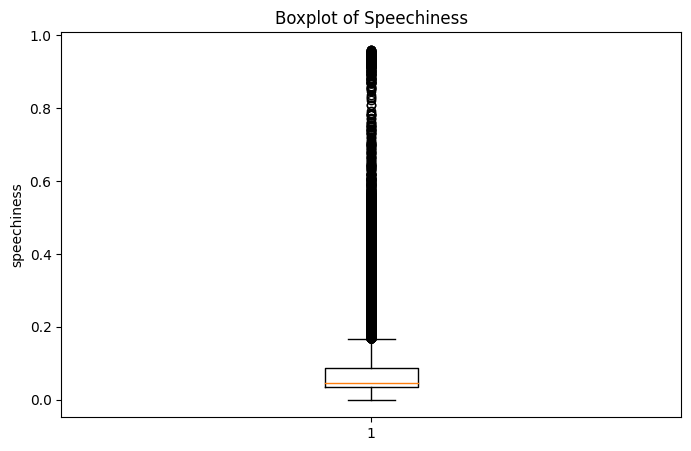

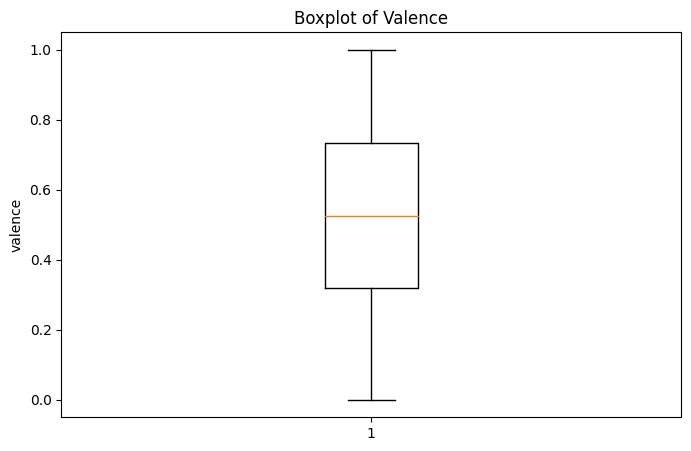

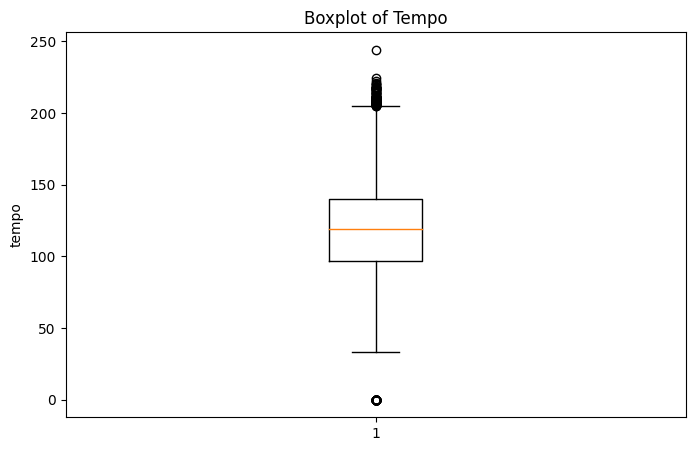

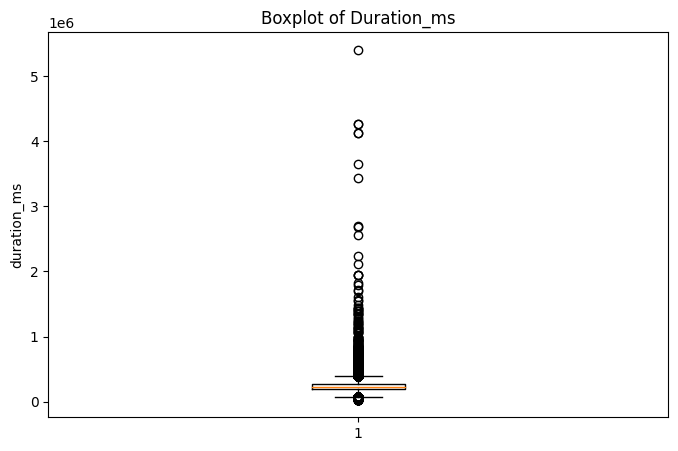

In [5]:
df = pd.read_csv("cleaned.csv")

features = ["acousticness", "speechiness", "valence", "tempo", "duration_ms"]

for feature in features:
    plt.figure(figsize=(8, 5))
    plt.boxplot(df[feature].dropna(), vert=True)
    plt.ylabel(feature)
    plt.title(f"Boxplot of {feature.capitalize()}")
    plt.show()

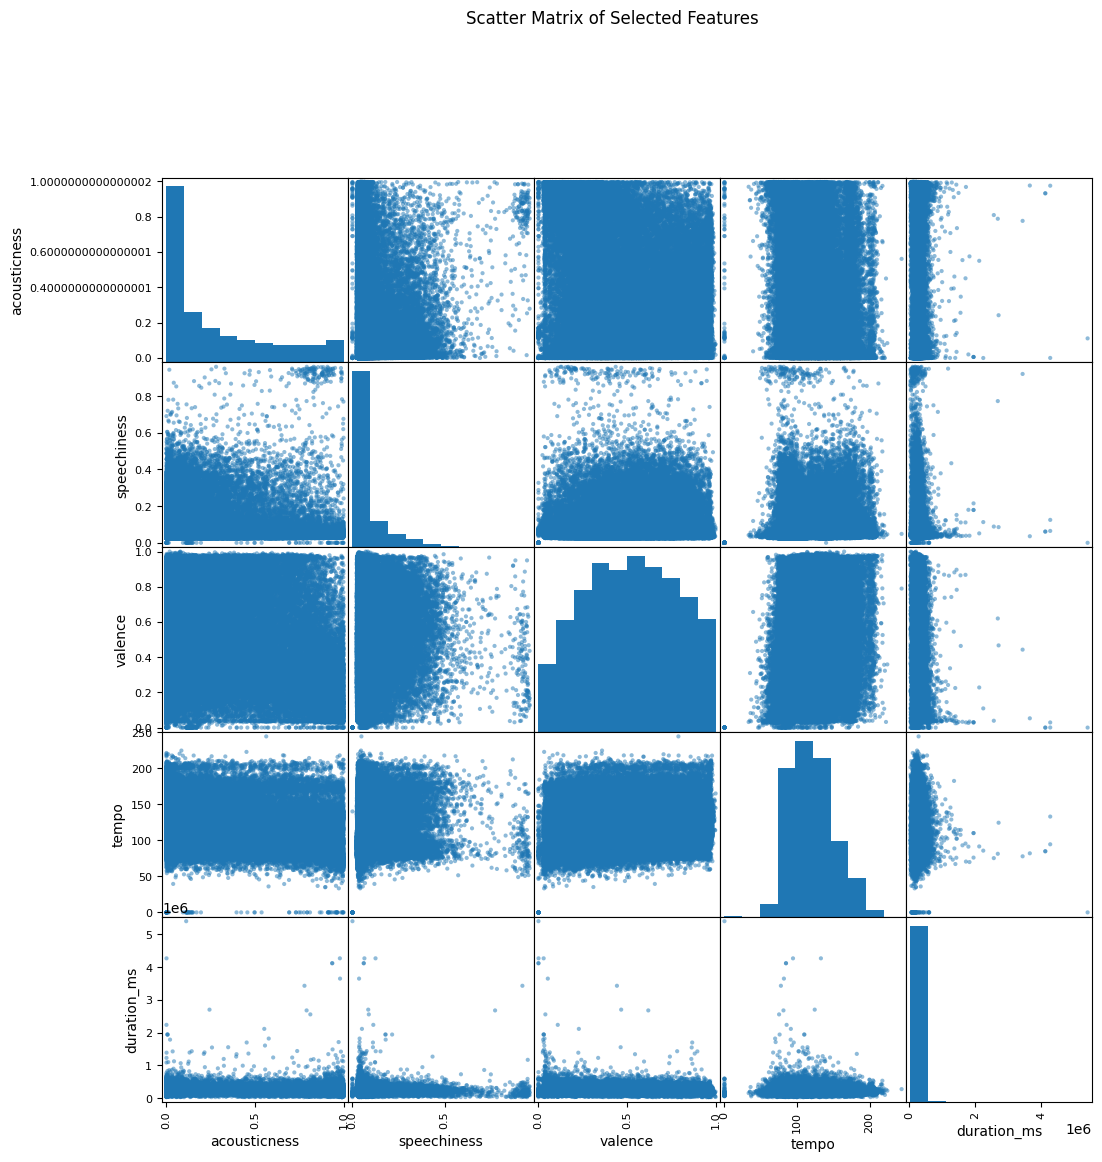

In [6]:
from pandas.plotting import scatter_matrix

df = pd.read_csv("cleaned.csv")

selected = df[["acousticness", "speechiness", "valence", "tempo", "duration_ms"]]

scatter_matrix(selected, figsize=(12, 12), diagonal="hist")
plt.suptitle("Scatter Matrix of Selected Features", y=1.02)
plt.show()